In [1]:
!pip install -q nltk spacy scikit-learn pandas numpy matplotlib seaborn networkx gensim
!python -m spacy download es_core_news_sm


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.9 MB 17.5 MB/s eta 0:00:01
     ---------------------------------- ---- 11.3/12.9 MB 44.0 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 35.2 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import json
import math
import random
import hashlib
import warnings
from collections import Counter
from itertools import combinations
import unicodedata
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import nltk
import spacy

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


warnings.filterwarnings("ignore")

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)

SEED_DATE = 20260707
SEED_RANDOM = 7726
SEMILLAPLN = SEED_DATE+SEED_RANDOM

print("SEMILLAPLN =", SEMILLAPLN)

SEMILLAPLN = 20268433


In [3]:
nlp = spacy.load("es_core_news_sm")

STOP_ES = set(stopwords.words("spanish"))
NEGACIONES_CONSERVAR = {"no", "ni", "nunca", "tampoco", "sin"}
STOP_ES = STOP_ES - NEGACIONES_CONSERVAR

print("spaCy model loaded correctly.")
print("Active stopwords:", len(STOP_ES))
print("Preserved negations:", NEGACIONES_CONSERVAR)

spaCy model loaded correctly.
Active stopwords: 310
Preserved negations: {'ni', 'sin', 'nunca', 'tampoco', 'no'}


In [4]:
CATEGORIAS = [
    "Residuos_Limpieza",
    "Movilidad_Transporte",
    "Alumbrado_Publico",
    "Ruido_Nocturno",
    "Zonas_Verdes"
]

URGENCIAS = ["Alta", "Media", "Baja"]

print("Thematic categories:", CATEGORIAS)
print("Urgency levels:", URGENCIAS)

datos_corpus = [
    # ======================================================
    # WASTE AND CLEANING
    # ======================================================
    {"texto_crudo": "FUEGO EN CONTENEDOR en c/ Colón nº32!! ruego policía o bomberos ya porque se pasa a los coches", "categoria": "Residuos_Limpieza", "urgencia": "Alta"},
    {"texto_crudo": "Han tirado jeringuillas y restos médicos al lado del parque de avd. Blasco Ibáñez, peligro para niños", "categoria": "Residuos_Limpieza", "urgencia": "Alta"},
    {"texto_crudo": "Gato muerto atropellado en plaza del ayuntamiento desde ayer por la tarde, huele fatal", "categoria": "Residuos_Limpieza", "urgencia": "Alta"},
    {"texto_crudo": "Contenedor volcado en medio de calle San Vicente, bloquea el paso", "categoria": "Residuos_Limpieza", "urgencia": "Alta"},
    {"texto_crudo": "Líquido raro saliendo de un camión de basura en Gran Vía Marqués del Turia", "categoria": "Residuos_Limpieza", "urgencia": "Alta"},
    {"texto_crudo": "Ratas enormes saliendo de un solar abandonado en calle Quart", "categoria": "Residuos_Limpieza", "urgencia": "Alta"},

    {"texto_crudo": "Muebles y colchón tirados en la acera de calle Colón desde el sábado", "categoria": "Residuos_Limpieza", "urgencia": "Media"},
    {"texto_crudo": "Basura acumulada fuera de los contenedores en avenida del Cid", "categoria": "Residuos_Limpieza", "urgencia": "Media"},
    {"texto_crudo": "Los contenedores de orgánico están rotos y no se pueden abrir", "categoria": "Residuos_Limpieza", "urgencia": "Media"},
    {"texto_crudo": "Papeleras de plaza de la Reina a rebosar todo el fin de semana", "categoria": "Residuos_Limpieza", "urgencia": "Media"},
    {"texto_crudo": "Huele muy mal cuando pasa el camión de la basura por calle Caballeros", "categoria": "Residuos_Limpieza", "urgencia": "Media"},
    {"texto_crudo": "Manchas de grasa en el suelo de avenida de Francia desde hace días", "categoria": "Residuos_Limpieza", "urgencia": "Media"},

    {"texto_crudo": "¿Dónde puedo reciclar pilas usadas cerca de Xàtiva?", "categoria": "Residuos_Limpieza", "urgencia": "Baja"},
    {"texto_crudo": "Quiero saber el horario del ecoparque móvil de Ruzafa", "categoria": "Residuos_Limpieza", "urgencia": "Baja"},
    {"texto_crudo": "Sugerencia: poner más contenedores de plástico en calle Sagunto", "categoria": "Residuos_Limpieza", "urgencia": "Baja"},
    {"texto_crudo": "¿A qué hora se puede tirar la basura legalmente?", "categoria": "Residuos_Limpieza", "urgencia": "Baja"},
    {"texto_crudo": "Consulta sobre recogida de trastos viejos en calle Cuba", "categoria": "Residuos_Limpieza", "urgencia": "Baja"},
    {"texto_crudo": "Felicitaciones a los barrenderos de la zona de calle Pelayo", "categoria": "Residuos_Limpieza", "urgencia": "Baja"},

    # ======================================================
    # MOBILITY AND TRANSPORT
    # ======================================================
    {"texto_crudo": "Semáforo roto en cruce de avenida Blasco Ibáñez con calle Rumiñahui", "categoria": "Movilidad_Transporte", "urgencia": "Alta"},
    {"texto_crudo": "Socavón enorme en carril bus de avenida del Cid", "categoria": "Movilidad_Transporte", "urgencia": "Alta"},
    {"texto_crudo": "Se ha caído una señal de dirección prohibida en calle San Vicente", "categoria": "Movilidad_Transporte", "urgencia": "Alta"},
    {"texto_crudo": "Aceite en la calzada en la rotonda de plaza España, varias motos resbalando", "categoria": "Movilidad_Transporte", "urgencia": "Alta"},
    {"texto_crudo": "Atropello por falta de visibilidad en paso de peatones de calle Sagunto", "categoria": "Movilidad_Transporte", "urgencia": "Alta"},
    {"texto_crudo": "Barrera del paso a nivel bajada desde hace media hora y no pasa ningún tren", "categoria": "Movilidad_Transporte", "urgencia": "Alta"},

    {"texto_crudo": "El bus 92 de EMT lleva 45 minutos de retraso", "categoria": "Movilidad_Transporte", "urgencia": "Media"},
    {"texto_crudo": "Obras sin señalizar junto al carril bici de avenida Francia", "categoria": "Movilidad_Transporte", "urgencia": "Media"},
    {"texto_crudo": "Coches en doble fila impiden pasar al autobús", "categoria": "Movilidad_Transporte", "urgencia": "Media"},
    {"texto_crudo": "Patinetes eléctricos circulando por la acera a gran velocidad", "categoria": "Movilidad_Transporte", "urgencia": "Media"},
    {"texto_crudo": "La app de EMT no funciona desde ayer", "categoria": "Movilidad_Transporte", "urgencia": "Media"},
    {"texto_crudo": "Falta pintura en el paso de peatones de calle Sagunto", "categoria": "Movilidad_Transporte", "urgencia": "Media"},

    {"texto_crudo": "¿Dónde puedo renovar el bono transporte para jubilados?", "categoria": "Movilidad_Transporte", "urgencia": "Baja"},
    {"texto_crudo": "Sugerencia: añadir un aparcabicis en calle Quart", "categoria": "Movilidad_Transporte", "urgencia": "Baja"},
    {"texto_crudo": "Consulta sobre ampliación del carril bici en Gran Vía", "categoria": "Movilidad_Transporte", "urgencia": "Baja"},
    {"texto_crudo": "El poste informativo de la parada de Xàtiva no se lee bien", "categoria": "Movilidad_Transporte", "urgencia": "Baja"},
    {"texto_crudo": "¿Se puede subir el perro al autobús de EMT?", "categoria": "Movilidad_Transporte", "urgencia": "Baja"},
    {"texto_crudo": "Me gustaría saber si cambiarán el sentido de circulación de mi calle", "categoria": "Movilidad_Transporte", "urgencia": "Baja"},

    # ======================================================
    # PUBLIC LIGHTING
    # ======================================================
    {"texto_crudo": "Toda la calle Quart a oscuras desde anoche, da mucho miedo pasar", "categoria": "Alumbrado_Publico", "urgencia": "Alta"},
    {"texto_crudo": "Cables pelados colgando de una farola rota en calle Colón 15", "categoria": "Alumbrado_Publico", "urgencia": "Alta"},
    {"texto_crudo": "Farola a punto de caerse tras golpe de camión en avenida del Cid", "categoria": "Alumbrado_Publico", "urgencia": "Alta"},
    {"texto_crudo": "Apagón general en Ruzafa desde hace dos horas", "categoria": "Alumbrado_Publico", "urgencia": "Alta"},
    {"texto_crudo": "Caja de conexiones abierta en farola de plaza del Ayuntamiento", "categoria": "Alumbrado_Publico", "urgencia": "Alta"},
    {"texto_crudo": "La farola de calle Caballeros echa chispas cuando llueve", "categoria": "Alumbrado_Publico", "urgencia": "Alta"},

    {"texto_crudo": "Farola parpadeando en avenida Blasco Ibáñez", "categoria": "Alumbrado_Publico", "urgencia": "Media"},
    {"texto_crudo": "Luz fundida en calle San Vicente 88", "categoria": "Alumbrado_Publico", "urgencia": "Media"},
    {"texto_crudo": "El reloj de encendido del alumbrado va mal en calle La Paz", "categoria": "Alumbrado_Publico", "urgencia": "Media"},
    {"texto_crudo": "La farola de plaza de la Reina apenas alumbra", "categoria": "Alumbrado_Publico", "urgencia": "Media"},
    {"texto_crudo": "Zumbido molesto del transformador de una farola", "categoria": "Alumbrado_Publico", "urgencia": "Media"},
    {"texto_crudo": "Los árboles tapan los focos en Gran Vía Marqués del Turia", "categoria": "Alumbrado_Publico", "urgencia": "Media"},

    {"texto_crudo": "¿A quién corresponde avisar para cambiar bombillas de farolas?", "categoria": "Alumbrado_Publico", "urgencia": "Baja"},
    {"texto_crudo": "Consulta sobre soterramiento de cables en mi barrio", "categoria": "Alumbrado_Publico", "urgencia": "Baja"},
    {"texto_crudo": "Sugerencia: iluminar más los monumentos del centro", "categoria": "Alumbrado_Publico", "urgencia": "Baja"},
    {"texto_crudo": "¿Hay previsto poner farolas solares en la zona nueva?", "categoria": "Alumbrado_Publico", "urgencia": "Baja"},
    {"texto_crudo": "Pregunta sobre consumo eléctrico del alumbrado público", "categoria": "Alumbrado_Publico", "urgencia": "Baja"},
    {"texto_crudo": "Gracias por arreglar tan rápido la luz de calle Ciscar", "categoria": "Alumbrado_Publico", "urgencia": "Baja"},

    # ======================================================
    # NIGHTTIME NOISE
    # ======================================================
    {"texto_crudo": "Fiesta ilegal en un piso de calle Caballeros desde la 1 de la madrugada", "categoria": "Ruido_Nocturno", "urgencia": "Alta"},
    {"texto_crudo": "Pelea de borrachos y botellas rotas en plaza Honduras", "categoria": "Ruido_Nocturno", "urgencia": "Alta"},
    {"texto_crudo": "Música altísima en local sin insonorizar de Ruzafa", "categoria": "Ruido_Nocturno", "urgencia": "Alta"},
    {"texto_crudo": "Alarma de negocio sonando sin parar desde ayer por la tarde", "categoria": "Ruido_Nocturno", "urgencia": "Alta"},
    {"texto_crudo": "Gritos y amenazas en la puerta de un pub en calle Quart", "categoria": "Ruido_Nocturno", "urgencia": "Alta"},
    {"texto_crudo": "Botellón enorme con gente chillando en el parque hasta las 4 am", "categoria": "Ruido_Nocturno", "urgencia": "Alta"},

    {"texto_crudo": "La terraza del bar recoge mesas a las 3 am haciendo mucho ruido", "categoria": "Ruido_Nocturno", "urgencia": "Media"},
    {"texto_crudo": "Camión de basura pasando de madrugada con mucho estruendo", "categoria": "Ruido_Nocturno", "urgencia": "Media"},
    {"texto_crudo": "Extractor de humos de una pizzería hace un ruido constante", "categoria": "Ruido_Nocturno", "urgencia": "Media"},
    {"texto_crudo": "Coches pitando por atasco nocturno cerca del centro", "categoria": "Ruido_Nocturno", "urgencia": "Media"},
    {"texto_crudo": "Ladridos continuos de perros en una terraza", "categoria": "Ruido_Nocturno", "urgencia": "Media"},
    {"texto_crudo": "Concierto con altavoces excesivos en plaza del Ayuntamiento", "categoria": "Ruido_Nocturno", "urgencia": "Media"},

    {"texto_crudo": "¿Cuál es el límite de decibelios permitido para una reforma?", "categoria": "Ruido_Nocturno", "urgencia": "Baja"},
    {"texto_crudo": "Consulta sobre ordenanza municipal del ruido para músicos", "categoria": "Ruido_Nocturno", "urgencia": "Baja"},
    {"texto_crudo": "Sugerencia: poner paneles acústicos en avenida del Cid", "categoria": "Ruido_Nocturno", "urgencia": "Baja"},
    {"texto_crudo": "¿Dónde puedo presentar una queja formal por ruido?", "categoria": "Ruido_Nocturno", "urgencia": "Baja"},
    {"texto_crudo": "Me gustaría saber si el ayuntamiento mide el ruido ambiental", "categoria": "Ruido_Nocturno", "urgencia": "Baja"},
    {"texto_crudo": "Pregunta sobre subvenciones para aislamiento acústico", "categoria": "Ruido_Nocturno", "urgencia": "Baja"},

    # ======================================================
    # GREEN AREAS AND PARKS
    # ======================================================
    {"texto_crudo": "Rama gigante caída en medio del parque de avenida Blasco Ibáñez", "categoria": "Zonas_Verdes", "urgencia": "Alta"},
    {"texto_crudo": "Árbol podrido a punto de romperse en jardín de calle Quart", "categoria": "Zonas_Verdes", "urgencia": "Alta"},
    {"texto_crudo": "Columpios rotos con hierros salientes en parque infantil", "categoria": "Zonas_Verdes", "urgencia": "Alta"},
    {"texto_crudo": "Enjambre enorme de abejas en un árbol de plaza del Ayuntamiento", "categoria": "Zonas_Verdes", "urgencia": "Alta"},
    {"texto_crudo": "Socavón peligroso tapado por hojas secas en los jardines del río", "categoria": "Zonas_Verdes", "urgencia": "Alta"},
    {"texto_crudo": "Palmera ardiendo por un petardo en la zona de San Vicente", "categoria": "Zonas_Verdes", "urgencia": "Alta"},

    {"texto_crudo": "Aspersores rotos inundando el paseo", "categoria": "Zonas_Verdes", "urgencia": "Media"},
    {"texto_crudo": "Falta de poda en jardines de calle Colón", "categoria": "Zonas_Verdes", "urgencia": "Media"},
    {"texto_crudo": "Cristales rotos en la zona canina del parque", "categoria": "Zonas_Verdes", "urgencia": "Media"},
    {"texto_crudo": "Setos descontrolados invadiendo el carril bici", "categoria": "Zonas_Verdes", "urgencia": "Media"},
    {"texto_crudo": "Hierba muy alta sin cortar desde hace un mes", "categoria": "Zonas_Verdes", "urgencia": "Media"},
    {"texto_crudo": "Bancos del parque llenos de pintadas y astillas", "categoria": "Zonas_Verdes", "urgencia": "Media"},

    {"texto_crudo": "¿Dónde puedo solicitar que planten un árbol en un alcorque vacío?", "categoria": "Zonas_Verdes", "urgencia": "Baja"},
    {"texto_crudo": "Sugerencia: poner más fuentes de agua potable en parques", "categoria": "Zonas_Verdes", "urgencia": "Baja"},
    {"texto_crudo": "Consulta sobre permisos para hacer fotos en jardines municipales", "categoria": "Zonas_Verdes", "urgencia": "Baja"},
    {"texto_crudo": "Me gustaría saber qué flores van a plantar esta temporada", "categoria": "Zonas_Verdes", "urgencia": "Baja"},
    {"texto_crudo": "¿Hay alguna asociación vecinal que cuide huertos urbanos?", "categoria": "Zonas_Verdes", "urgencia": "Baja"},
    {"texto_crudo": "Felicitaciones por el mantenimiento de los parterres del barrio", "categoria": "Zonas_Verdes", "urgencia": "Baja"},
]

Thematic categories: ['Residuos_Limpieza', 'Movilidad_Transporte', 'Alumbrado_Publico', 'Ruido_Nocturno', 'Zonas_Verdes']
Urgency levels: ['Alta', 'Media', 'Baja']


In [5]:
df = pd.DataFrame(datos_corpus)
df.index.name = "id_mensaje"
df = df.reset_index()

texto_bloque_bruto = " ".join(df["texto_crudo"].tolist()).encode("utf-8")
hash_bruto = hashlib.sha256(texto_bloque_bruto).hexdigest()

print("Total corpus volume:", len(df))
print("SHA-256 hash raw corpus:", hash_bruto)
print("\nDistribution by category:")
print(df["categoria"].value_counts())
print("\nDistribution by urgency:")
print(df["urgencia"].value_counts())

df.head()

Total corpus volume: 90
SHA-256 hash raw corpus: d6c9b300ca6a77ff7f52ecd6e9a11264df3de9d4110312292a41705fbb69634b

Distribution by category:
categoria
Residuos_Limpieza       18
Movilidad_Transporte    18
Alumbrado_Publico       18
Ruido_Nocturno          18
Zonas_Verdes            18
Name: count, dtype: int64

Distribution by urgency:
urgencia
Alta     30
Media    30
Baja     30
Name: count, dtype: int64


,id_mensaje,texto_crudo,categoria,urgencia
0,0,FUEGO EN CONTENEDOR en c/ Colón nº32!! ruego p...,Residuos_Limpieza,Alta
1,1,Han tirado jeringuillas y restos médicos al la...,Residuos_Limpieza,Alta
2,2,Gato muerto atropellado en plaza del ayuntamie...,Residuos_Limpieza,Alta
3,3,Contenedor volcado en medio de calle San Vicen...,Residuos_Limpieza,Alta
4,4,Líquido raro saliendo de un camión de basura e...,Residuos_Limpieza,Alta


**TASK 1.2 PREPROCESSING**

In [6]:
ABREVIATURAS_URBANAS = {
    "c/": "calle",
    "c.": "calle",
    "c ": "calle ",
    "avd.": "avenida",
    "avd": "avenida",
    "av.": "avenida",
    "av ": "avenida ",
    "pza": "plaza",
    "plz": "plaza",
    "nº": "numero",
    "n°": "numero",
    "n.": "numero",
    "emt": "emt",
    "app": "aplicacion",
    "am": "am",
    "pm": "pm"
}

ERRORES_FRECUENTES = {
    "haber si": "a ver si",
    "aver": "a ver",
    "xq": "porque",
    "xk": "porque",
    "q ": "que ",
    "dnd": "donde",
    "tb": "tambien",
    "k ": "que ",
    "pa ": "para ",
    "porfa": "por favor",
    "urgue": "urge",
    "urje": "urge"
}

In [7]:
def eliminar_html_urls(texto):
    texto = re.sub(r"<[^>]+>", " ", texto)
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    return texto

def normalizar_espacios(texto):
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def expandir_abreviaturas(texto):
    t = " " + texto + " "
    for k, v in ABREVIATURAS_URBANAS.items():
        t = t.replace(k, v)
    for k, v in ERRORES_FRECUENTES.items():
        t = t.replace(k, v)
    return normalizar_espacios(t)

def quitar_acentos(texto):
    return "".join(
        c for c in unicodedata.normalize("NFD", texto)
        if unicodedata.category(c) != "Mn"
    )

def limpieza_basica(texto):
    t = eliminar_html_urls(texto)
    t = t.lower()
    t = expandir_abreviaturas(t)
    t = quitar_acentos(t)
    t = re.sub(r"[^a-z0-9ñ\s]", " ", t)
    t = normalizar_espacios(t)
    return t

def tokenizar_filtrar(texto_normalizado):
    doc = nlp(texto_normalizado)
    tokens = []
    for tok in doc:
        if tok.is_space:
            continue
        if tok.is_punct:
            continue
        if tok.text in STOP_ES:
            continue
        if len(tok.text) <= 1 and not tok.text.isdigit():
            continue
        tokens.append(tok.text)
    return tokens

def lematizar_tokens(lista_tokens):
    doc = nlp(" ".join(lista_tokens))
    lemas = []
    for tok in doc:
        lema = tok.lemma_.strip()
        if not lema:
            continue
        if lema == "-PRON-":
            continue
        if lema in STOP_ES:
            continue
        if len(lema) <= 1 and not lema.isdigit():
            continue
        lemas.append(lema)
    return lemas

def extraer_entidades(texto_original):
    doc = nlp(texto_original)
    return [(ent.text, ent.label_) for ent in doc.ents]

def pipeline_preprocesado(texto):
    texto_norm = limpieza_basica(texto)
    tokens = tokenizar_filtrar(texto_norm)
    lemas = lematizar_tokens(tokens)
    texto_preprocesado = " ".join(lemas)
    return texto_norm, tokens, lemas, texto_preprocesado

In [8]:
resultado_pipeline = df["texto_crudo"].apply(pipeline_preprocesado)

df["texto_normalizado"] = resultado_pipeline.apply(lambda x: x[0])
df["tokens"] = resultado_pipeline.apply(lambda x: x[1])
df["lemas"] = resultado_pipeline.apply(lambda x: x[2])
df["texto_preprocesado"] = resultado_pipeline.apply(lambda x: x[3])
df["entidades"] = df["texto_crudo"].apply(extraer_entidades)

print("Pipeline applied correctly.")
df.head(5)

Pipeline applied correctly.


,id_mensaje,texto_crudo,categoria,urgencia,texto_normalizado,tokens,lemas,texto_preprocesado,entidades
0,0,FUEGO EN CONTENEDOR en c/ Colón nº32!! ruego p...,Residuos_Limpieza,Alta,fuego en contenedor en calle colon numero32 ru...,"[fuego, contenedor, calle, colon, numero32, ru...","[fuego, contenedor, calle, colon, numero32, ru...",fuego contenedor calle colon numero32 ruego po...,"[(FUEGO, ORG), (Colón nº32!!, MISC)]"
1,1,Han tirado jeringuillas y restos médicos al la...,Residuos_Limpieza,Alta,han tirado jeringuillas y restos medicos al la...,"[tirado, jeringuillas, restos, medicos, lado, ...","[tirar, jeringuilla, resto, medico, lado, parq...",tirar jeringuilla resto medico lado parque ave...,"[(parque de avd, LOC), (Blasco Ibáñez, PER)]"
2,2,Gato muerto atropellado en plaza del ayuntamie...,Residuos_Limpieza,Alta,gato muerto atropellado en plaza del ayuntamie...,"[gato, muerto, atropellado, plaza, ayuntamient...","[gato, muerto, atropellado, plaza, ayuntamient...",gato muerto atropellado plaza ayuntamiento aye...,[]
3,3,Contenedor volcado en medio de calle San Vicen...,Residuos_Limpieza,Alta,contenedor volcado en medio de calle san vicen...,"[contenedor, volcado, medio, calle, san, vicen...","[contenedor, volcado, medio, calle, san, vicen...",contenedor volcado medio calle san vicente blo...,"[(calle San Vicente, LOC)]"
4,4,Líquido raro saliendo de un camión de basura e...,Residuos_Limpieza,Alta,liquido raro saliendo de un camion de basura e...,"[liquido, raro, saliendo, camion, basura, gran...","[liquido, raro, salir, camion, basura, gran, v...",liquido raro salir camion basura gran via marq...,"[(Gran Vía Marqués del Turia, LOC)]"


In [9]:
antes = len(df)

df = df.drop_duplicates(subset=["texto_preprocesado"]).copy()
df = df[df["texto_preprocesado"].str.strip().astype(bool)].copy()
df = df.reset_index(drop=True)

despues = len(df)

print("Messages before quality control:", antes)
print("Messages after quality control:", despues)
print("Deleted messages:", antes - despues)

Messages before quality control: 90
Messages after quality control: 90
Deleted messages: 0


In [10]:
texto_bloque_limpio = " ".join(df["texto_preprocesado"].tolist()).encode("utf-8")
hash_limpio = hashlib.sha256(texto_bloque_limpio).hexdigest()

print("SHA-256 HASH raw corpus : ", hash_bruto)
print("SHA-256 HASH clean corpus:", hash_limpio)

SHA-256 HASH raw corpus :  d6c9b300ca6a77ff7f52ecd6e9a11264df3de9d4110312292a41705fbb69634b
SHA-256 HASH clean corpus: 77352cc1a2bca3fa8316380c6ea0a6978cf5d42f430b4d9c98e2d50a08aa834b


In [11]:
muestra_ids = [0, 18, 54]

for idx in muestra_ids:
    fila = df.loc[idx]
    print("=" * 90)
    print(f"ID: {fila['id_mensaje']}")
    print("ORIGINAL       :", fila["texto_crudo"])
    print("NORMALIZED    :", fila["texto_normalizado"])
    print("TOKENS         :", fila["tokens"])
    print("LEMMAS         :", fila["lemas"])
    print("PREPROCESSED   :", fila["texto_preprocesado"])
    print("ENTITIES      :", fila["entidades"])
    print("CATEGORY       :", fila["categoria"])
    print("URGENCY       :", fila["urgencia"])

ID: 0
ORIGINAL       : FUEGO EN CONTENEDOR en c/ Colón nº32!! ruego policía o bomberos ya porque se pasa a los coches
NORMALIZED    : fuego en contenedor en calle colon numero32 ruego policia o bomberos ya porque se pasa a los coches
TOKENS         : ['fuego', 'contenedor', 'calle', 'colon', 'numero32', 'ruego', 'policia', 'bomberos', 'pasa', 'coches']
LEMMAS         : ['fuego', 'contenedor', 'calle', 'colon', 'numero32', 'ruego', 'policiar', 'bombero', 'pasar', 'coche']
PREPROCESSED   : fuego contenedor calle colon numero32 ruego policiar bombero pasar coche
ENTITIES      : [('FUEGO', 'ORG'), ('Colón nº32!!', 'MISC')]
CATEGORY       : Residuos_Limpieza
URGENCY       : Alta
ID: 18
ORIGINAL       : Semáforo roto en cruce de avenida Blasco Ibáñez con calle Rumiñahui
NORMALIZED    : semaforo roto en cruce de avenida blasco ibanez con calle ruminahui
TOKENS         : ['semaforo', 'roto', 'cruce', 'avenida', 'blasco', 'ibanez', 'calle', 'ruminahui']
LEMMAS         : ['semaforir', 'roto', 'c

In [12]:
ficha_corpus = {
    "nombre_corpus": "URBAN-PLN-Valencia",
    "caso_uso": "Clasificación y priorización de incidencias urbanas municipales",
    "procedencia": "Mensajes sintéticos controlados, redactados por Gemini, para fines docentes",
    "idioma": "Español",
    "volumen_mensajes": int(len(df)),
    "numero_categorias": int(df["categoria"].nunique()),
    "numero_urgencias": int(df["urgencia"].nunique()),
    "categorias": sorted(df["categoria"].unique().tolist()),
    "urgencias": sorted(df["urgencia"].unique().tolist()),
    "sesgos_previsibles": [
        "Corpus pequeño",
        "Lenguaje controlado y parcialmente balanceado",
        "Cobertura limitada de variantes dialectales",
        "Posible exceso de vocabulario prototípico por categoría"
    ],
    "limitaciones": [
        "No contiene datos reales de producción",
        "No incluye audio ni transcripciones automáticas",
        "NER en español puede fallar en calles y abreviaturas"
    ],
    "anonimizacion": "No se incluyen datos personales reales; nombres y referencias son ficticios o genéricos"
}

print(json.dumps(ficha_corpus, indent=4, ensure_ascii=False))


{
    "nombre_corpus": "URBAN-PLN-Valencia",
    "caso_uso": "Clasificación y priorización de incidencias urbanas municipales",
    "procedencia": "Mensajes sintéticos controlados, redactados por Gemini, para fines docentes",
    "idioma": "Español",
    "volumen_mensajes": 90,
    "numero_categorias": 5,
    "numero_urgencias": 3,
    "categorias": [
        "Alumbrado_Publico",
        "Movilidad_Transporte",
        "Residuos_Limpieza",
        "Ruido_Nocturno",
        "Zonas_Verdes"
    ],
    "urgencias": [
        "Alta",
        "Baja",
        "Media"
    ],
    "sesgos_previsibles": [
        "Corpus pequeño",
        "Lenguaje controlado y parcialmente balanceado",
        "Cobertura limitada de variantes dialectales",
        "Posible exceso de vocabulario prototípico por categoría"
    ],
    "limitaciones": [
        "No contiene datos reales de producción",
        "No incluye audio ni transcripciones automáticas",
        "NER en español puede fallar en calles y abrevia

**Task 1.2 Comments**
- Negation is kept because it can alter priority and meaning.
- Urban abbreviations are expanded to reduce lexical dispersion.
- Lemmatization is applied to unify morphological variants.
- Entities are extracted for their contextual value, although they are not yet used as a direct feature.
- The hash of the clean corpus differs from the raw one because noise, punctuation, and superficial variation have been removed.


**TASK 1.3**

In [13]:
vectorizador_bow = CountVectorizer(
    max_features=800,
    ngram_range=(1, 2),
    min_df=1
)

X_bow = vectorizador_bow.fit_transform(df["texto_preprocesado"])
vocab_bow = vectorizador_bow.get_feature_names_out()

print("BoW Matrix:", X_bow.shape)
print("First 25 vocabulary terms:")
print(vocab_bow[:25])

BoW Matrix: (90, 772)
First 25 vocabulary terms:
['15' '45' '45 minuto' '88' '92' '92 emt' 'abandonado' 'abandonado calle'
 'abeja' 'abeja arbol' 'abierto' 'abierto farola' 'abrir' 'aceite'
 'aceite calzado' 'acera' 'acera calle' 'acera gran' 'acumulado'
 'acumulado contenedor' 'acustico' 'acustico avenida' 'agua'
 'agua potable' 'aislamiento']


In [14]:
vectorizador_tfidf_global = TfidfVectorizer(
    max_features=800,
    ngram_range=(1, 2),
    min_df=1,
)

X_tfidf_global = vectorizador_tfidf_global.fit_transform(df["texto_preprocesado"])
vocab_tfidf = vectorizador_tfidf_global.get_feature_names_out()

print("Global TF-IDF matrix:", X_tfidf_global.shape)
print("TF-IDF vocabulary size:", len(vocab_tfidf))
print(vocab_tfidf[:25])

Global TF-IDF matrix: (90, 772)
TF-IDF vocabulary size: 772
['15' '45' '45 minuto' '88' '92' '92 emt' 'abandonado' 'abandonado calle'
 'abeja' 'abeja arbol' 'abierto' 'abierto farola' 'abrir' 'aceite'
 'aceite calzado' 'acera' 'acera calle' 'acera gran' 'acumulado'
 'acumulado contenedor' 'acustico' 'acustico avenida' 'agua'
 'agua potable' 'aislamiento']


In [15]:
X_embeddings_spacy = np.array([nlp(texto).vector for texto in df["texto_preprocesado"]])

print("spaCy embeddings matrix:", X_embeddings_spacy.shape)
print("Document embedding dimension:", X_embeddings_spacy.shape[1])

spaCy embeddings matrix: (90, 96)
Document embedding dimension: 96


In [16]:
tabla_repr = pd.DataFrame([
    {
        "Representacion": "Bag of Words",
        "Dimensionalidad": X_bow.shape[1],
        "Interpretabilidad": "Alta",
        "Coste_computacional": "Bajo",
        "Capacidad_semantica": "Baja",
        "Utilidad_principal": "Clasificación base e inspección léxica"
    },
    {
        "Representacion": "TF-IDF",
        "Dimensionalidad": X_tfidf_global.shape[1],
        "Interpretabilidad": "Alta",
        "Coste_computacional": "Bajo-Medio",
        "Capacidad_semantica": "Media",
        "Utilidad_principal": "Clasificación y recuperación"
    },
    {
        "Representacion": "Embeddings spaCy",
        "Dimensionalidad": X_embeddings_spacy.shape[1],
        "Interpretabilidad": "Media-Baja",
        "Coste_computacional": "Medio",
        "Capacidad_semantica": "Media",
        "Utilidad_principal": "Similitud semántica complementaria"
    }
])

tabla_repr

,Representacion,Dimensionalidad,Interpretabilidad,Coste_computacional,Capacidad_semantica,Utilidad_principal
0,Bag of Words,772,Alta,Bajo,Baja,Clasificación base e inspección léxica
1,TF-IDF,772,Alta,Bajo-Medio,Media,Clasificación y recuperación
2,Embeddings spaCy,96,Media-Baja,Medio,Media,Similitud semántica complementaria


In [17]:
df_tfidf = pd.DataFrame(X_tfidf_global.toarray(), columns=vocab_tfidf)
df_tfidf["categoria"] = df["categoria"].values

top_terminos_por_categoria = {}

for cat in sorted(df["categoria"].unique()):
    medias = df_tfidf[df_tfidf["categoria"] == cat].drop(columns=["categoria"]).mean(axis=0)
    top = medias.sort_values(ascending=False).head(10)
    top_terminos_por_categoria[cat] = top.index.tolist()

for cat, lista in top_terminos_por_categoria.items():
    print("=" * 80)
    print(cat)
    print(", ".join(lista))

Alumbrado_Publico
farola, calle, farola plaza, luz, alumbrado, plaza, avenida, molesto, transformador, transformador farola
Movilidad_Transporte
calle, emt, carril, no, pasar, autobus, avenida, peatón, peatón calle, bus
Residuos_Limpieza
contenedor, calle, basura, poder, tirar, salir, oler, camion basura, camion, colon
Ruido_Nocturno
ruido, acustico, terrazar, musico, hacer ruido, am, ayuntamiento, sin, hacer, ladrido continuo
Zonas_Verdes
jardín, roto, arbol, parque, zona, hacer, inundar, paseo, aspersor, inundar paseo


In [18]:
tabla_top_terminos = pd.DataFrame(
    [(cat, ", ".join(terms[:8])) for cat, terms in top_terminos_por_categoria.items()],
    columns=["Categoria", "Terminos_TFIDF_dominantes"]
)

tabla_top_terminos

,Categoria,Terminos_TFIDF_dominantes
0,Alumbrado_Publico,"farola, calle, farola plaza, luz, alumbrado, p..."
1,Movilidad_Transporte,"calle, emt, carril, no, pasar, autobus, avenid..."
2,Residuos_Limpieza,"contenedor, calle, basura, poder, tirar, salir..."
3,Ruido_Nocturno,"ruido, acustico, terrazar, musico, hacer ruido..."
4,Zonas_Verdes,"jardín, roto, arbol, parque, zona, hacer, inun..."


In [19]:
df[["id_mensaje", "texto_crudo", "categoria", "urgencia"]].to_csv("corpus_bruto.csv", index=False, encoding="utf-8")
df[["id_mensaje", "texto_preprocesado", "categoria", "urgencia"]].to_csv("corpus_limpio.csv", index=False, encoding="utf-8")

diccionario_etiquetas = {
    "categorias": CATEGORIAS,
    "urgencias": URGENCIAS,
    "hash_bruto": hash_bruto,
    "hash_limpio": hash_limpio,
    "semilla": SEMILLAPLN
}

with open("diccionario_etiquetas.json", "w", encoding="utf-8") as f:
    json.dump(diccionario_etiquetas, f, ensure_ascii=False, indent=4)

print("Files saved successfully.")

Files saved successfully.


**PART 2**
**TASK 2.1**

In [20]:
X_texto = df["texto_preprocesado"]
y_categoria = df["categoria"]
y_urgencia = df["urgencia"]

print("Number of documents:", len(X_texto))
print("Categories:", sorted(y_categoria.unique()))
print("Urgencies:", sorted(y_urgencia.unique()))

Number of documents: 90
Categories: ['Alumbrado_Publico', 'Movilidad_Transporte', 'Residuos_Limpieza', 'Ruido_Nocturno', 'Zonas_Verdes']
Urgencies: ['Alta', 'Baja', 'Media']


In [21]:
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=1
    )),
    ("clf", MultinomialNB())
])

pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=1
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=SEMILLAPLN,
        class_weight="balanced"
    ))
])

modelos = {
    "TFIDF + NaiveBayes": pipe_nb,
    "TFIDF + RegresionLogistica": pipe_lr
}

In [22]:
cv_estratificada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEMILLAPLN
)

resultados_categoria = []

for nombre_modelo, modelo in modelos.items():
    scores = cross_validate(
        modelo,
        X_texto,
        y_categoria,
        cv=cv_estratificada,
        scoring={
            "accuracy": "accuracy",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted"
        },
        n_jobs=None
    )
    
    resultados_categoria.append({
        "modelo": nombre_modelo,
        "accuracy_medio": scores["test_accuracy"].mean(),
        "precision_macro_media": scores["test_precision_macro"].mean(),
        "recall_macro_media": scores["test_recall_macro"].mean(),
        "f1_macro_media": scores["test_f1_macro"].mean(),
        "f1_weighted_media": scores["test_f1_weighted"].mean(),
        "std_f1_weighted": scores["test_f1_weighted"].std()
    })

df_resultados_categoria = pd.DataFrame(resultados_categoria).sort_values(
    by="f1_weighted_media",
    ascending=False
)

print("CV RESULTS · TOPIC CLASSIFICATION")
display(df_resultados_categoria.round(4))

CV RESULTS · TOPIC CLASSIFICATION


,modelo,accuracy_medio,precision_macro_media,recall_macro_media,f1_macro_media,f1_weighted_media,std_f1_weighted
1,TFIDF + RegresionLogistica,0.3333,0.3609,0.3367,0.3127,0.3144,0.1140
0,TFIDF + NaiveBayes,0.2889,0.3201,0.3000,0.2755,0.2727,0.1156


CLASSIFICATION REPORT · CATEGORY
                      precision    recall  f1-score   support

   Alumbrado_Publico     0.6667    0.4000    0.5000         5
Movilidad_Transporte     0.3750    0.7500    0.5000         4
   Residuos_Limpieza     0.3750    0.6000    0.4615         5
      Ruido_Nocturno     1.0000    0.2000    0.3333         5
        Zonas_Verdes     0.3333    0.2500    0.2857         4

            accuracy                         0.4348        23
           macro avg     0.5500    0.4400    0.4161        23
        weighted avg     0.5670    0.4348    0.4181        23



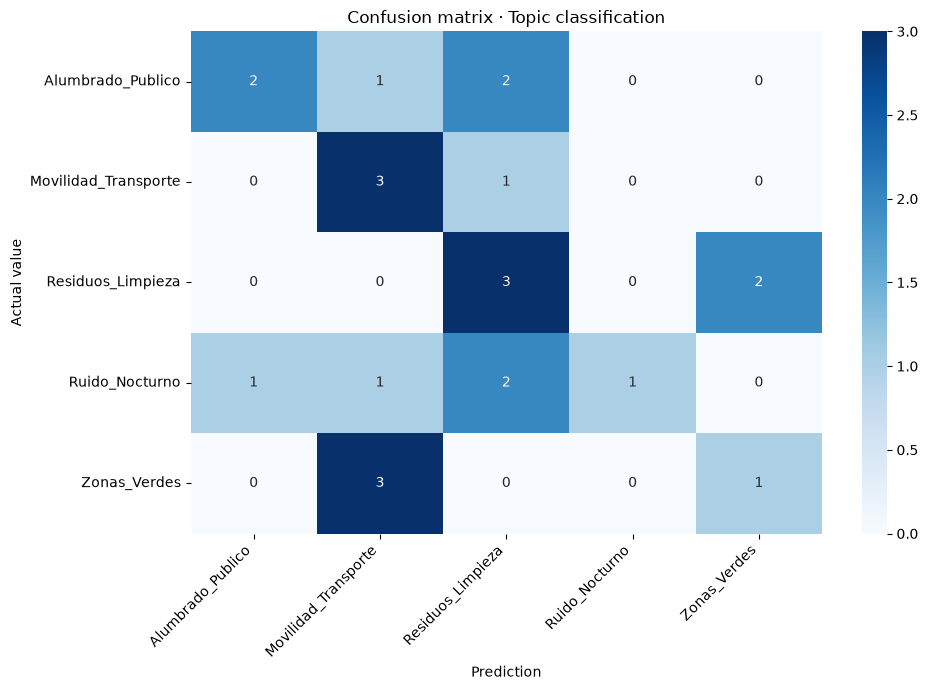

In [23]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_texto,
    y_categoria,
    test_size=0.25,
    stratify=y_categoria,
    random_state=SEMILLAPLN
)

modelo_categoria_final = pipe_lr
modelo_categoria_final.fit(X_train_cat, y_train_cat)

y_pred_cat = modelo_categoria_final.predict(X_test_cat)

print("CLASSIFICATION REPORT · CATEGORY")
print(classification_report(y_test_cat, y_pred_cat, digits=4))

cm_cat = confusion_matrix(y_test_cat, y_pred_cat, labels=modelo_categoria_final.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_cat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=modelo_categoria_final.classes_,
    yticklabels=modelo_categoria_final.classes_
)
plt.title("Confusion matrix · Topic classification")
plt.xlabel("Prediction")
plt.ylabel("Actual value")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
df_errores_categoria = pd.DataFrame({
    "texto_original": X_test_cat.values,
    "categoria_real": y_test_cat.values,
    "categoria_predicha": y_pred_cat
})

df_errores_categoria = df_errores_categoria[
    df_errores_categoria["categoria_real"] != df_errores_categoria["categoria_predicha"]
].reset_index(drop=True)

print("TOPIC CLASSIFICATION ERRORS")
display(df_errores_categoria.head(10))

TOPIC CLASSIFICATION ERRORS


,texto_original,categoria_real,categoria_predicha
0,papelera plaza reina rebosar fin semana,Residuos_Limpieza,Zonas_Verdes
1,seto descontrolado invadir carril bici,Zonas_Verdes,Movilidad_Transporte
2,calle quart oscura anoche dar miedo pasar,Alumbrado_Publico,Residuos_Limpieza
3,arbol podrido punto romper él jardin calle quart,Zonas_Verdes,Movilidad_Transporte
4,gustario saber si ayuntamiento medir ruido amb...,Ruido_Nocturno,Movilidad_Transporte
5,sugerencia poner mas contenedor plastico calle...,Residuos_Limpieza,Zonas_Verdes
6,arbol tapar foco gran via marques turio,Alumbrado_Publico,Movilidad_Transporte
7,coche pitar atasco nocturno cerca centro,Ruido_Nocturno,Alumbrado_Publico
8,alarmar negocio sonar sin parar ayer tarde,Ruido_Nocturno,Residuos_Limpieza
9,camion basura pasar madrugado estruendo,Ruido_Nocturno,Residuos_Limpieza


In [25]:
resultados_urgencia = []

for nombre_modelo, modelo in modelos.items():
    scores = cross_validate(
        modelo,
        X_texto,
        y_urgencia,
        cv=cv_estratificada,
        scoring={
            "accuracy": "accuracy",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted"
        },
        n_jobs=None
    )
    
    resultados_urgencia.append({
        "modelo": nombre_modelo,
        "accuracy_medio": scores["test_accuracy"].mean(),
        "precision_macro_media": scores["test_precision_macro"].mean(),
        "recall_macro_media": scores["test_recall_macro"].mean(),
        "f1_macro_media": scores["test_f1_macro"].mean(),
        "f1_weighted_media": scores["test_f1_weighted"].mean(),
        "std_f1_weighted": scores["test_f1_weighted"].std()
    })

df_resultados_urgencia = pd.DataFrame(resultados_urgencia).sort_values(
    by="f1_weighted_media",
    ascending=False
)

print("CV RESULTS · URGENCY CLASSIFICATION")
display(df_resultados_urgencia.round(4))

CV RESULTS · URGENCY CLASSIFICATION


,modelo,accuracy_medio,precision_macro_media,recall_macro_media,f1_macro_media,f1_weighted_media,std_f1_weighted
0,TFIDF + NaiveBayes,0.5556,0.5519,0.5556,0.5310,0.5310,0.0511
1,TFIDF + RegresionLogistica,0.5556,0.5279,0.5556,0.5271,0.5271,0.0555


CLASSIFICATION REPORT · URGENCY
              precision    recall  f1-score   support

        Alta     0.5455    0.8571    0.6667         7
        Baja     0.5714    0.5000    0.5333         8
       Media     0.6000    0.3750    0.4615         8

    accuracy                         0.5652        23
   macro avg     0.5723    0.5774    0.5538        23
weighted avg     0.5735    0.5652    0.5489        23



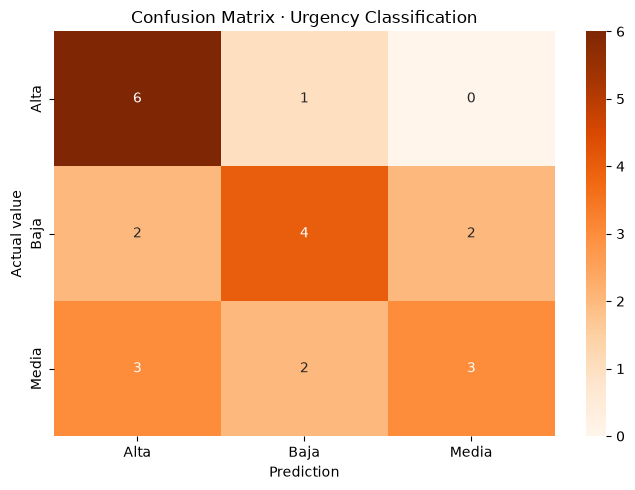

In [26]:
X_train_urg, X_test_urg, y_train_urg, y_test_urg = train_test_split(
    X_texto,
    y_urgencia,
    test_size=0.25,
    stratify=y_urgencia,
    random_state=SEMILLAPLN
)

modelo_urgencia_final = pipe_nb
modelo_urgencia_final.fit(X_train_urg, y_train_urg)

y_pred_urg = modelo_urgencia_final.predict(X_test_urg)

print("CLASSIFICATION REPORT · URGENCY")
print(classification_report(y_test_urg, y_pred_urg, digits=4))

cm_urg = confusion_matrix(y_test_urg, y_pred_urg, labels=modelo_urgencia_final.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_urg,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=modelo_urgencia_final.classes_,
    yticklabels=modelo_urgencia_final.classes_
)
plt.title("Confusion Matrix · Urgency Classification")
plt.xlabel("Prediction")
plt.ylabel("Actual value")
plt.tight_layout()
plt.show()

In [27]:
mejor_tematica = df_resultados_categoria.iloc[0]["modelo"]
mejor_urgencia = df_resultados_urgencia.iloc[0]["modelo"]

print("SELECTED MODEL FOR CATEGORY:", mejor_tematica)
print("SELECTED MODEL FOR URGENCY:", mejor_urgencia)
print("\nSuggested justification:")
print("- Weighted F1 is prioritized due to possible sensitivity to class differences.")
print("- Logistic Regression usually offers better balance between performance and interpretability.")
print("- TF-IDF maintains lexical traceability, low computational cost and ease of auditing.")

SELECTED MODEL FOR CATEGORY: TFIDF + RegresionLogistica
SELECTED MODEL FOR URGENCY: TFIDF + NaiveBayes

Suggested justification:
- Weighted F1 is prioritized due to possible sensitivity to class differences.
- Logistic Regression usually offers better balance between performance and interpretability.
- TF-IDF maintains lexical traceability, low computational cost and ease of auditing.


**TASK 2.2**

In [28]:
vectorizador_lsi = vectorizador_tfidf_global

vectorizador_lda = vectorizador_bow

X_lsi = vectorizador_lsi.fit_transform(df["texto_preprocesado"])
X_lda = vectorizador_lda.fit_transform(df["texto_preprocesado"])

feature_names_lsi = vectorizador_lsi.get_feature_names_out()
feature_names_lda = vectorizador_lda.get_feature_names_out()

print("LSI matrix:", X_lsi.shape)
print("LDA matrix:", X_lda.shape)

LSI matrix: (90, 772)
LDA matrix: (90, 772)


In [29]:
def mostrar_topicos(modelo, feature_names, n_top_palabras=8, prefijo="Topico"):
    salida = {}
    for idx, topic in enumerate(modelo.components_):
        top_idx = topic.argsort()[-n_top_palabras:][::-1]
        palabras = [feature_names[i] for i in top_idx]
        pesos = [topic[i] for i in top_idx]
        salida[f"{prefijo}_{idx+1}"] = list(zip(palabras, np.round(pesos, 4)))
    return salida

k_lsi_a = 5
k_lsi_b = 7

lsi_a = TruncatedSVD(n_components=k_lsi_a, random_state=SEMILLAPLN)
lsi_b = TruncatedSVD(n_components=k_lsi_b, random_state=SEMILLAPLN)

lsi_a.fit(X_lsi)
lsi_b.fit(X_lsi)

print("Cumulative explained variance LSI k=5:", round(lsi_a.explained_variance_ratio_.sum(), 4))
print("Cumulative explained variance LSI k=7:", round(lsi_b.explained_variance_ratio_.sum(), 4))

topicos_lsi_a = mostrar_topicos(lsi_a, feature_names_lsi, n_top_palabras=8, prefijo="LSI5")
topicos_lsi_b = mostrar_topicos(lsi_b, feature_names_lsi, n_top_palabras=8, prefijo="LSI7")

print("\nLSI TOPICS k=5")
for nombre, palabras in topicos_lsi_a.items():
    print(nombre, "->", ", ".join([p for p, _ in palabras]))

Cumulative explained variance LSI k=5: 0.0871
Cumulative explained variance LSI k=7: 0.1221

LSI TOPICS k=5
LSI5_1 -> calle, avenida, farola, ibanez, blasco, avenida blasco, blasco ibanez, sugerencia
LSI5_2 -> avenida, avenida blasco, blasco, ibanez, blasco ibanez, parque, parque avenida, farola
LSI5_3 -> gran, gran via, via, basura, camion, carril, camion basura, marques turio
LSI5_4 -> sugerencia, poner, sugerencia poner, mas, poner mas, sagunto, calle sagunto, quart
LSI5_5 -> saber, gustario saber, gustario, si, saber si, ruido, farola, ayuntamiento


In [30]:
k_lda_a = 5
k_lda_b = 7

lda_a = LatentDirichletAllocation(
    n_components=k_lda_a,
    random_state=SEMILLAPLN,
    learning_method="batch"
)

lda_b = LatentDirichletAllocation(
    n_components=k_lda_b,
    random_state=SEMILLAPLN,
    learning_method="batch"
)

lda_a.fit(X_lda)
lda_b.fit(X_lda)

print("Perplexity LDA k=5:", round(lda_a.perplexity(X_lda), 4))
print("Perplexity LDA k=7:", round(lda_b.perplexity(X_lda), 4))

topicos_lda_a = mostrar_topicos(lda_a, feature_names_lda, n_top_palabras=8, prefijo="LDA5")
topicos_lda_b = mostrar_topicos(lda_b, feature_names_lda, n_top_palabras=8, prefijo="LDA7")

print("\nLDA TOPICS k=5")
for nombre, palabras in topicos_lda_a.items():
    print(nombre, "->", ", ".join([p for p, _ in palabras]))

Perplexity LDA k=5: 1379.261
Perplexity LDA k=7: 1465.2047

LDA TOPICS k=5
LDA5_1 -> calle, contenedor, calle colon, colon, pasar, ruzafa, roto, farola
LDA5_2 -> calle, plaza, hacer, farola, enorme, arbol, ayuntamiento, plaza ayuntamiento
LDA5_3 -> calle, avenida, sugerencia, poner, farola, roto, parque, sugerencia poner
LDA5_4 -> sin, poder, emt, avenida, ayer, calle, carril bici, bici
LDA5_5 -> pasar, hacer, calle, ruido, saber, basura, no, carril


For LDA k=5, we could assign a name to some topics: Mobility to topic 4 and Maintenance to topic 1. The rest present quite a bit of noise that at first glance would not make us think what context they suggest, since between them they repeat words like streetlight or garbage.

In [31]:
dist_doc_topico_lda_a = lda_a.transform(X_lda)
df_topicos = pd.DataFrame(dist_doc_topico_lda_a, columns=[f"topico_{i+1}" for i in range(k_lda_a)])
df_topicos["topico_dominante"] = df_topicos.idxmax(axis=1)
df_topicos["categoria_real"] = df["categoria"].values
df_topicos["texto_preprocesado"] = df["texto_preprocesado"].values

print("SAMPLE OF DOCUMENTS WITH DOMINANT TOPIC")
display(df_topicos.head(10))

SAMPLE OF DOCUMENTS WITH DOMINANT TOPIC


,topico_1,topico_2,topico_3,topico_4,topico_5,topico_dominante,categoria_real,texto_preprocesado
0,0.959899,0.010009,0.010019,0.010016,0.010057,topico_1,Residuos_Limpieza,fuego contenedor calle colon numero32 ruego po...
1,0.009103,0.009097,0.009321,0.009171,0.963308,topico_5,Residuos_Limpieza,tirar jeringuilla resto medico lado parque ave...
2,0.011124,0.955366,0.011133,0.011234,0.011142,topico_2,Residuos_Limpieza,gato muerto atropellado plaza ayuntamiento aye...
3,0.949588,0.012598,0.012652,0.012509,0.012654,topico_1,Residuos_Limpieza,contenedor volcado medio calle san vicente blo...
4,0.011131,0.955089,0.011202,0.011138,0.011440,topico_2,Residuos_Limpieza,liquido raro salir camion basura gran via marq...
5,0.014379,0.942566,0.014432,0.014303,0.014318,topico_2,Residuos_Limpieza,rata enorme salir solar abandonado calle quart
6,0.942732,0.014304,0.014307,0.014359,0.014298,topico_1,Residuos_Limpieza,mueble colchon tirado acera calle colon sabado
7,0.919463,0.020058,0.020251,0.020004,0.020223,topico_1,Residuos_Limpieza,basura acumulado contenedor avenido cid
8,0.017009,0.016669,0.016907,0.016805,0.932610,topico_5,Residuos_Limpieza,contenedor organico roto no poder abrir
9,0.016678,0.933294,0.016670,0.016682,0.016678,topico_2,Residuos_Limpieza,papelera plaza reina rebosar fin semana


In [32]:
tabla_cruce_topicos = pd.crosstab(
    df_topicos["topico_dominante"],
    df_topicos["categoria_real"],
    normalize="index"
).round(3)

print("DOMINANT TOPIC vs ACTUAL CATEGORY CROSSING")
display(tabla_cruce_topicos)

DOMINANT TOPIC vs ACTUAL CATEGORY CROSSING


categoria_real,Alumbrado_Publico,Movilidad_Transporte,Residuos_Limpieza,Ruido_Nocturno,Zonas_Verdes
topico_dominante,,,,,
topico_1,0.200,0.150,0.250,0.300,0.100
topico_2,0.304,0.043,0.304,0.130,0.217
topico_3,0.235,0.118,0.118,0.118,0.412
topico_4,0.000,0.636,0.091,0.182,0.091
topico_5,0.158,0.263,0.158,0.263,0.158


**Task 2.3**

In [33]:
vectorizador_recuperacion = vectorizador_tfidf_global

modelo_categoria_rec = LogisticRegression(
    max_iter=2000,
    random_state=SEMILLAPLN,
    class_weight="balanced"
)
modelo_categoria_rec.fit(X_tfidf_global, df["categoria"])

#we will use logistic regression here for simplicity, in addition to the fact that naive bayes gave similar metrics
modelo_urgencia_rec = LogisticRegression(
    max_iter=2000,
    random_state=SEMILLAPLN,
    class_weight="balanced"
)
modelo_urgencia_rec.fit(X_tfidf_global, df["urgencia"])

print("Global retrieval matrix:", X_tfidf_global.shape)

Global retrieval matrix: (90, 772)


In [34]:
def recomendar_actuacion(categoria, urgencia):
    if urgencia == "Alta":
        return "Derivación inmediata al servicio municipal y apertura de incidencia prioritaria"
    elif urgencia == "Media":
        return "Registro ordinario con revisión técnica en el mismo ciclo de trabajo"
    else:
        return "Respuesta informativa o incorporación a planificación"


def recuperar_incidencias(consulta, n_resultados=3):
    _, _, _, consulta_pre = pipeline_preprocesado(consulta)
    
    query_vec = vectorizador_recuperacion.transform([consulta_pre])
    similitudes = cosine_similarity(query_vec, X_tfidf_global)[0]
    
    indices_top = similitudes.argsort()[-n_resultados:][::-1]
    
    categoria_pred = modelo_categoria_rec.predict(query_vec)[0]
    urgencia_pred = modelo_urgencia_rec.predict(query_vec)[0]
    recomendacion = recomendar_actuacion(categoria_pred, urgencia_pred)
    
    resultados = []
    for idx in indices_top:
        fila = df.iloc[idx]
        resultados.append({
            "id_mensaje": int(fila["id_mensaje"]),
            "similitud": round(float(similitudes[idx]), 4),
            "categoria_real": fila["categoria"],
            "urgencia_real": fila["urgencia"],
            "texto_original": fila["texto_crudo"]
        })
    
    return {
        "consulta_original": consulta,
        "consulta_preprocesada": consulta_pre,
        "categoria_predicha": categoria_pred,
        "urgencia_predicha": urgencia_pred,
        "recomendacion": recomendacion,
        "resultados": resultados
    }

In [35]:
consultas_prueba = [
    "Hay cristales rotos y peligro en un parque infantil del barrio",
    "La farola de mi calle lleva apagada desde anoche",
    "Huele fatal al lado de los contenedores y hay basura fuera",
    "Hay una fiesta con música muy alta en un piso de madrugada",
    "Un coche mal aparcado bloquea el paso del autobús"
]

for i, consulta in enumerate(consultas_prueba, start=1):
    salida = recuperar_incidencias(consulta, n_resultados=3)
    
    print("=" * 90)
    print(f"QUERY {i}: {salida['consulta_original']}")
    print("Preprocessed query:", salida["consulta_preprocesada"])
    print("Predicted category:", salida["categoria_predicha"])
    print("Predicted urgency:", salida["urgencia_predicha"])
    print("Recommendation:", salida["recomendacion"])
    print("-" * 90)
    
    for r in salida["resultados"]:
        print(f"ID {r['id_mensaje']} | Similarity={r['similitud']} | {r['categoria_real']} | {r['urgencia_real']}")
        print("Message:", r["texto_original"])
        print()

QUERY 1: Hay cristales rotos y peligro en un parque infantil del barrio
Preprocessed query: cristal roto peligro parque infantil barrio
Predicted category: Zonas_Verdes
Predicted urgency: Alta
Recommendation: Derivación inmediata al servicio municipal y apertura de incidencia prioritaria
------------------------------------------------------------------------------------------
ID 80 | Similarity=0.4228 | Zonas_Verdes | Media
Message: Cristales rotos en la zona canina del parque

ID 74 | Similarity=0.3705 | Zonas_Verdes | Alta
Message: Columpios rotos con hierros salientes en parque infantil

ID 1 | Similarity=0.1414 | Residuos_Limpieza | Alta
Message: Han tirado jeringuillas y restos médicos al lado del parque de avd. Blasco Ibáñez, peligro para niños

QUERY 2: La farola de mi calle lleva apagada desde anoche
Preprocessed query: farola calle llevar apagado anoche
Predicted category: Alumbrado_Publico
Predicted urgency: Alta
Recommendation: Derivación inmediata al servicio municipal y a

In [36]:
filas_recuperacion = []

for consulta in consultas_prueba:
    salida = recuperar_incidencias(consulta, n_resultados=3)
    for rank, r in enumerate(salida["resultados"], start=1):
        filas_recuperacion.append({
            "consulta": salida["consulta_original"],
            "categoria_predicha": salida["categoria_predicha"],
            "urgencia_predicha": salida["urgencia_predicha"],
            "rank": rank,
            "id_mensaje": r["id_mensaje"],
            "similitud": r["similitud"],
            "categoria_real_doc": r["categoria_real"],
            "urgencia_real_doc": r["urgencia_real"]
        })

df_recuperacion = pd.DataFrame(filas_recuperacion)
display(df_recuperacion)

,consulta,categoria_predicha,urgencia_predicha,rank,id_mensaje,similitud,categoria_real_doc,urgencia_real_doc
0,Hay cristales rotos y peligro en un parque inf...,Zonas_Verdes,Alta,1,80,0.4228,Zonas_Verdes,Media
1,Hay cristales rotos y peligro en un parque inf...,Zonas_Verdes,Alta,2,74,0.3705,Zonas_Verdes,Alta
2,Hay cristales rotos y peligro en un parque inf...,Zonas_Verdes,Alta,3,1,0.1414,Residuos_Limpieza,Alta
3,La farola de mi calle lleva apagada desde anoche,Alumbrado_Publico,Alta,1,41,0.2860,Alumbrado_Publico,Alta
4,La farola de mi calle lleva apagada desde anoche,Alumbrado_Publico,Alta,2,36,0.1947,Alumbrado_Publico,Alta
5,La farola de mi calle lleva apagada desde anoche,Alumbrado_Publico,Alta,3,24,0.1471,Movilidad_Transporte,Media
6,Huele fatal al lado de los contenedores y hay ...,Residuos_Limpieza,Media,1,2,0.3259,Residuos_Limpieza,Alta
7,Huele fatal al lado de los contenedores y hay ...,Residuos_Limpieza,Media,2,10,0.1983,Residuos_Limpieza,Media
8,Huele fatal al lado de los contenedores y hay ...,Residuos_Limpieza,Media,3,7,0.1897,Residuos_Limpieza,Media
9,Hay una fiesta con música muy alta en un piso ...,Ruido_Nocturno,Alta,1,54,0.4332,Ruido_Nocturno,Alta


In [37]:
G = nx.Graph()

for lemas in df["lemas"]:
    nodos_validos = sorted(set([t for t in lemas if len(t) > 3]))
    for u, v in combinations(nodos_validos, 2):
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
        else:
            G.add_edge(u, v, weight=1)

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

Graph nodes: 322
Graph edges: 1208


In [38]:
grado_centralidad = nx.degree_centrality(G)
betweenness_centralidad = nx.betweenness_centrality(G, normalized=True)

top_grado = sorted(grado_centralidad.items(), key=lambda x: x[1], reverse=True)[:10]
top_betweenness = sorted(betweenness_centralidad.items(), key=lambda x: x[1], reverse=True)[:10]

print("TOP 10 NODES BY DEGREE")
for nodo, valor in top_grado:
    print(nodo, "->", round(valor, 4))

print("\nTOP 10 NODES BY BETWEENNESS")
for nodo, valor in top_betweenness:
    print(nodo, "->", round(valor, 4))

TOP 10 NODES BY DEGREE
calle -> 0.2897
avenida -> 0.1308
farola -> 0.1215
pasar -> 0.1121
plaza -> 0.1059
hacer -> 0.1028
roto -> 0.0997
poder -> 0.0903
parque -> 0.081
contenedor -> 0.0779

TOP 10 NODES BY BETWEENNESS
calle -> 0.3244
poder -> 0.1107
avenida -> 0.103
roto -> 0.0935
farola -> 0.0893
plaza -> 0.0814
hacer -> 0.0722
ayuntamiento -> 0.0615
arbol -> 0.0524
ruido -> 0.0518


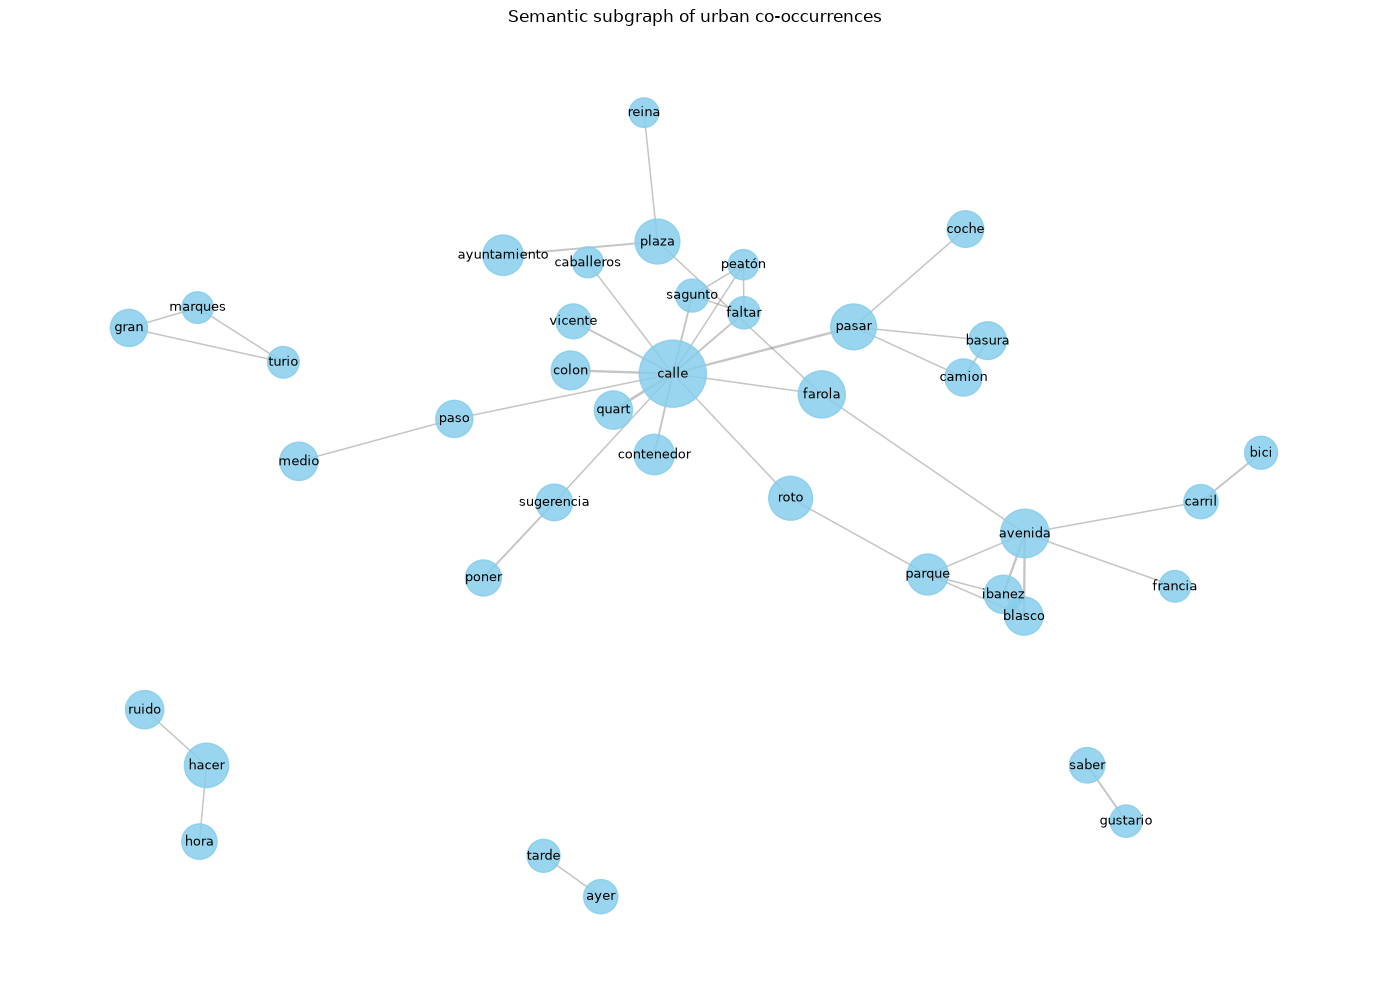

In [39]:
umbral_peso = 2
G_sub = nx.Graph(
    [(u, v, d) for u, v, d in G.edges(data=True) if d["weight"] >= umbral_peso]
)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_sub, k=0.45, seed=SEMILLAPLN)

node_sizes = []
for n in G_sub.nodes():
    node_sizes.append(300 + 7000 * grado_centralidad.get(n, 0))

edge_widths = [0.5 + d["weight"] * 0.3 for _, _, d in G_sub.edges(data=True)]

nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes, node_color="skyblue", alpha=0.85)
nx.draw_networkx_edges(G_sub, pos, width=edge_widths, alpha=0.45, edge_color="gray")
nx.draw_networkx_labels(G_sub, pos, font_size=9)

plt.title("Semantic subgraph of urban co-occurrences")
plt.axis("off")
plt.tight_layout()
plt.show()

In [40]:
relaciones_fuertes = []

for u, v, d in G.edges(data=True):
    if d["weight"] >= 3:
        relaciones_fuertes.append((u, v, d["weight"]))

df_relaciones_fuertes = pd.DataFrame(
    relaciones_fuertes,
    columns=["termino_1", "termino_2", "peso_coocurrencia"]
).sort_values(by="peso_coocurrencia", ascending=False)

print("STRONGEST SEMANTIC RELATIONS")
display(df_relaciones_fuertes.head(20))

STRONGEST SEMANTIC RELATIONS


,termino_1,termino_2,peso_coocurrencia
4,calle,quart,5
2,calle,pasar,4
0,calle,colon,4
8,avenida,ibanez,4
9,blasco,ibanez,4
7,avenida,blasco,4
1,calle,contenedor,3
6,calle,faltar,3
5,calle,sagunto,3
3,calle,vicente,3


In [41]:
def sistema_municipal_nlp(consulta):
    salida = recuperar_incidencias(consulta, n_resultados=3)
    
    respuesta = {
        "consulta": salida["consulta_original"],
        "categoria_probable": salida["categoria_predicha"],
        "urgencia_estimada": salida["urgencia_predicha"],
        "recomendacion_actuacion": salida["recomendacion"],
        "mensajes_relacionados": salida["resultados"]
    }
    return respuesta

ejemplo_sistema = sistema_municipal_nlp("Hay una rama caída y riesgo para niños en el parque")
display(ejemplo_sistema)

{'consulta': 'Hay una rama caída y riesgo para niños en el parque',
 'categoria_probable': 'Zonas_Verdes',
 'urgencia_estimada': 'Alta',
 'recomendacion_actuacion': 'Derivación inmediata al servicio municipal y apertura de incidencia prioritaria',
 'mensajes_relacionados': [{'id_mensaje': 72,
   'similitud': 0.3914,
   'categoria_real': 'Zonas_Verdes',
   'urgencia_real': 'Alta',
   'texto_original': 'Rama gigante caída en medio del parque de avenida Blasco Ibáñez'},
  {'id_mensaje': 1,
   'similitud': 0.1965,
   'categoria_real': 'Residuos_Limpieza',
   'urgencia_real': 'Alta',
   'texto_original': 'Han tirado jeringuillas y restos médicos al lado del parque de avd. Blasco Ibáñez, peligro para niños'},
  {'id_mensaje': 80,
   'similitud': 0.1128,
   'categoria_real': 'Zonas_Verdes',
   'urgencia_real': 'Media',
   'texto_original': 'Cristales rotos en la zona canina del parque'}]}

**TASK 3.2**

In [42]:

consultas_prueba_32 = [
    {
        "id_prueba": 1,
        "mensaje": "Semáforo roto en cruce de avenida Blasco Ibáñez con calle Rumiñahui",
        "categoria_esperada": "Movilidad_Transporte",
        "prioridad_esperada": "Alta",
        "tipo_caso": "facil"
    },
    {
        "id_prueba": 2,
        "mensaje": "¿Dónde puedo reciclar pilas usadas cerca de Xàtiva?",
        "categoria_esperada": "Residuos_Limpieza",
        "prioridad_esperada": "Baja",
        "tipo_caso": "facil"
    },
    {
        "id_prueba": 3,
        "mensaje": "Toda la calle Quart a oscuras desde anoche, da mucho miedo pasar",
        "categoria_esperada": "Alumbrado_Publico",
        "prioridad_esperada": "Alta",
        "tipo_caso": "critico"
    },
    {
        "id_prueba": 4,
        "mensaje": "La terraza del bar recoge mesas a las 3 am haciendo mucho ruido",
        "categoria_esperada": "Ruido_Nocturno",
        "prioridad_esperada": "Media",
        "tipo_caso": "facil"
    },
    {
        "id_prueba": 5,
        "mensaje": "Árbol podrido a punto de romperse en jardín de calle Quart",
        "categoria_esperada": "Zonas_Verdes",
        "prioridad_esperada": "Alta",
        "tipo_caso": "critico"
    },
    {
        "id_prueba": 6,
        "mensaje": "El poste informativo de la parada de Xàtiva no se lee bien",
        "categoria_esperada": "Movilidad_Transporte",
        "prioridad_esperada": "Baja",
        "tipo_caso": "ambiguo"
    },
    {
        "id_prueba": 7,
        "mensaje": "Papeleras de plaza de la Reina a rebosar todo el fin de semana",
        "categoria_esperada": "Residuos_Limpieza",
        "prioridad_esperada": "Media",
        "tipo_caso": "facil"
    },
    {
        "id_prueba": 8,
        "mensaje": "Botellón enorme con gente chillando en el parque hasta las 4 am",
        "categoria_esperada": "Ruido_Nocturno",
        "prioridad_esperada": "Alta",
        "tipo_caso": "critico"
    }
]

df_pruebas_32 = pd.DataFrame(consultas_prueba_32)
df_pruebas_32

,id_prueba,mensaje,categoria_esperada,prioridad_esperada,tipo_caso
0,1,Semáforo roto en cruce de avenida Blasco Ibáñe...,Movilidad_Transporte,Alta,facil
1,2,¿Dónde puedo reciclar pilas usadas cerca de Xà...,Residuos_Limpieza,Baja,facil
2,3,"Toda la calle Quart a oscuras desde anoche, da...",Alumbrado_Publico,Alta,critico
3,4,La terraza del bar recoge mesas a las 3 am hac...,Ruido_Nocturno,Media,facil
4,5,Árbol podrido a punto de romperse en jardín de...,Zonas_Verdes,Alta,critico
5,6,El poste informativo de la parada de Xàtiva no...,Movilidad_Transporte,Baja,ambiguo
6,7,Papeleras de plaza de la Reina a rebosar todo ...,Residuos_Limpieza,Media,facil
7,8,Botellón enorme con gente chillando en el parq...,Ruido_Nocturno,Alta,critico


In [43]:
prompt_clasificacion_v1 = """
Analiza el siguiente mensaje ciudadano y devuelve la categoría, la prioridad,
un resumen y una justificación breve en formato JSON.

Mensaje: {mensaje_usuario}
Contexto recuperado: {contexto_recuperado}
"""

prompt_clasificacion_v2 = """
[ROL]
Actúa como analista de PLN para un sistema municipal de atención ciudadana.

[CONTEXTO]
Tu tarea es analizar mensajes breves enviados por ciudadanía sobre incidencias o consultas urbanas.
Las categorías posibles son:
- Residuos_Limpieza
- Movilidad_Transporte
- Alumbrado_Publico
- Ruido_Nocturno
- Zonas_Verdes

Los niveles de prioridad posibles son:
- Alta
- Media
- Baja

[ENTRADA_CIUDADANO]
<<<MENSAJE>>>
{mensaje_usuario}
<<<FIN_MENSAJE>>>

[CONTEXTO_RECUPERADO]
<<<SIMILARES>>>
{contexto_recuperado}
<<<FIN_SIMILARES>>>

[INSTRUCCIONES]
1. Identifica la categoría más probable.
2. Estima la prioridad del caso.
3. Resume el mensaje en una sola frase breve.
4. Justifica la decisión de forma concisa y basada solo en el mensaje y el contexto recuperado.
5. Si el caso es ambiguo, indícalo en la justificación.

[RESTRICCIONES]
- No inventes datos.
- No añadas normativa no proporcionada.
- No supongas ubicación exacta si no aparece.
- No uses más categorías o prioridades que las permitidas.
- Si dudas entre dos categorías, elige la más probable y explica la ambigüedad.

[FORMATO_SALIDA]
Devuelve solo un JSON válido con esta estructura:
{
  "categoria": "",
  "prioridad": "",
  "resumen": "",
  "justificacion": ""
}
"""

In [44]:
prompt_respuesta_ciudadana = """
[ROL]
Actúa como asistente municipal de atención ciudadana.

[CONTEXTO]
Debes redactar una primera respuesta para una persona que ha enviado una incidencia o consulta urbana.
La respuesta debe ser comprensible, correcta y prudente.

[DATOS_ESTRUCTURADOS]
<<<DATOS>>>
Categoría: {categoria}
Prioridad: {prioridad}
Resumen: {resumen}
Justificación: {justificacion}
Contexto recuperado: {contexto_recuperado}
<<<FIN_DATOS>>>

[INSTRUCCIONES]
1. Redacta una respuesta breve para el ciudadano.
2. Reconoce el problema o la consulta sin exagerar.
3. Indica que el caso será revisado o derivado según corresponda.
4. Si la prioridad es alta, expresa urgencia operativa sin prometer una resolución inmediata.
5. Si faltan datos relevantes, solicítalos de forma breve y educada.

[RESTRICCIONES]
- No prometas actuaciones concretas que no consten en el sistema.
- No inventes teléfonos, plazos ni normas.
- No uses lenguaje alarmista.
- No des consejos de emergencia salvo que el caso sea claramente crítico.

[FORMATO_SALIDA]
Devuelve solo un JSON válido con esta estructura:
{
  "respuesta_ciudadano": ""
}
"""

In [45]:
prompt_derivacion_interna = """
[ROL]
Actúa como sistema interno de triaje municipal.

[CONTEXTO]
Debes generar una derivación breve para el servicio municipal competente a partir del análisis previo de un mensaje ciudadano.

[DATOS_ESTRUCTURADOS]
<<<DATOS>>>
Mensaje original: {mensaje_usuario}
Categoría: {categoria}
Prioridad: {prioridad}
Resumen: {resumen}
Justificación: {justificacion}
Contexto recuperado: {contexto_recuperado}
<<<FIN_DATOS>>>

[MAPA_SERVICIOS]
- Residuos_Limpieza -> Servicio de Limpieza y Residuos
- Movilidad_Transporte -> Servicio de Movilidad
- Alumbrado_Publico -> Servicio de Alumbrado
- Ruido_Nocturno -> Policía Local / Inspección
- Zonas_Verdes -> Servicio de Jardinería y Parques

[INSTRUCCIONES]
1. Determina el servicio destino.
2. Indica si debe activarse una alerta crítica.
3. Resume el caso en lenguaje operativo.
4. Justifica la derivación en una frase.

[RESTRICCIONES]
- No inventes unidades no incluidas en el mapa.
- No declares alerta crítica sin base en el mensaje o en la prioridad.
- Si el caso es ambiguo, mantén el servicio más probable e indica revisión manual.

[FORMATO_SALIDA]
Devuelve solo un JSON válido con esta estructura:
{
  "servicio_destino": "",
  "alerta": false,
  "resumen_interno": "",
  "justificacion_derivacion": ""
}
"""

In [46]:
MAPA_SERVICIOS = {
    "Residuos_Limpieza": "Servicio de Limpieza y Residuos",
    "Movilidad_Transporte": "Servicio de Movilidad",
    "Alumbrado_Publico": "Servicio de Alumbrado",
    "Ruido_Nocturno": "Policía Local / Inspección",
    "Zonas_Verdes": "Servicio de Jardinería y Parques"
}

def recuperar_similares(mensaje, top_k=3):
    consulta_proc = pipeline_preprocesado(mensaje)[3]
    query_vec = vectorizador_tfidf_global.transform([consulta_proc])
    sims = cosine_similarity(query_vec, X_tfidf_global)[0]
    idx_top = np.argsort(sims)[::-1][:top_k]
    
    resultados = []
    for idx in idx_top:
        resultados.append({
            "id_mensaje": int(df.iloc[idx]["id_mensaje"]),
            "texto": df.iloc[idx]["texto_crudo"],
            "categoria": df.iloc[idx]["categoria"],
            "urgencia": df.iloc[idx]["urgencia"],
            "similitud": float(round(sims[idx], 4))
        })
    return resultados

def clasificar_mensaje_simulado(mensaje):
    mensaje_proc = pipeline_preprocesado(mensaje)[3]
    vec = vectorizador_tfidf_global.transform([mensaje_proc])
    
    categoria_pred = modelo_categoria_rec.predict(vec)[0]
    urgencia_pred = modelo_urgencia_rec.predict(vec)[0]
    similares = recuperar_similares(mensaje, top_k=3)
    similitud_max = similares[0]["similitud"] if len(similares) > 0 else 0.0
    
    resumen = mensaje.strip()
    if len(resumen) > 110:
        resumen = resumen[:107] + "..."
    
    justificacion = (
        f"Se asigna la categoría {categoria_pred} y la prioridad {urgencia_pred} "
        f"por el contenido léxico del mensaje y su similitud con incidencias previas del corpus."
    )
    
    respuesta_ciudadano = (
        f"Se ha registrado su mensaje como {categoria_pred.replace('_', ' ').lower()} "
        f"con prioridad {urgencia_pred.lower()}. "
        f"El caso será revisado por el servicio correspondiente."
    )
    
    if urgencia_pred == "Alta":
        respuesta_ciudadano += " Dada la posible urgencia, se priorizará su revisión operativa."
    
    servicio_destino = MAPA_SERVICIOS.get(categoria_pred, "Revisión manual")
    
    resumen_interno = (
        f"Incidencia clasificada en {categoria_pred} con prioridad {urgencia_pred}. "
        f"Mensaje resumido: {resumen}"
    )
    
    justificacion_derivacion = (
        f"Se deriva a {servicio_destino} por tratarse de una incidencia compatible con la categoría detectada."
    )
    
    salida = {
        "categoria": categoria_pred,
        "prioridad": urgencia_pred,
        "resumen": resumen,
        "justificacion": justificacion,
        "respuesta_ciudadano": respuesta_ciudadano,
        "servicio_destino": servicio_destino,
        "resumen_interno": resumen_interno,
        "justificacion_derivacion": justificacion_derivacion,
        "contexto_recuperado": similares
    }
    
    return salida

In [47]:
resultados_32 = []

for _, fila in df_pruebas_32.iterrows():
    salida = clasificar_mensaje_simulado(fila["mensaje"])
    
    resultados_32.append({
        "id_prueba": fila["id_prueba"],
        "tipo_caso": fila["tipo_caso"],
        "mensaje": fila["mensaje"],
        "categoria_esperada": fila["categoria_esperada"],
        "categoria_obtenida": salida["categoria"],
        "prioridad_esperada": fila["prioridad_esperada"],
        "prioridad_obtenida": salida["prioridad"],
        "servicio_destino": salida["servicio_destino"],
        "respuesta_ciudadano": salida["respuesta_ciudadano"]
    })

df_resultados_32 = pd.DataFrame(resultados_32)
df_resultados_32

,id_prueba,tipo_caso,mensaje,categoria_esperada,categoria_obtenida,prioridad_esperada,prioridad_obtenida,servicio_destino,respuesta_ciudadano
0,1,facil,Semáforo roto en cruce de avenida Blasco Ibáñe...,Movilidad_Transporte,Movilidad_Transporte,Alta,Alta,Servicio de Movilidad,Se ha registrado su mensaje como movilidad tra...
1,2,facil,¿Dónde puedo reciclar pilas usadas cerca de Xà...,Residuos_Limpieza,Residuos_Limpieza,Baja,Baja,Servicio de Limpieza y Residuos,Se ha registrado su mensaje como residuos limp...
2,3,critico,"Toda la calle Quart a oscuras desde anoche, da...",Alumbrado_Publico,Alumbrado_Publico,Alta,Alta,Servicio de Alumbrado,Se ha registrado su mensaje como alumbrado pub...
3,4,facil,La terraza del bar recoge mesas a las 3 am hac...,Ruido_Nocturno,Ruido_Nocturno,Media,Media,Policía Local / Inspección,Se ha registrado su mensaje como ruido nocturn...
4,5,critico,Árbol podrido a punto de romperse en jardín de...,Zonas_Verdes,Zonas_Verdes,Alta,Alta,Servicio de Jardinería y Parques,Se ha registrado su mensaje como zonas verdes ...
5,6,ambiguo,El poste informativo de la parada de Xàtiva no...,Movilidad_Transporte,Movilidad_Transporte,Baja,Baja,Servicio de Movilidad,Se ha registrado su mensaje como movilidad tra...
6,7,facil,Papeleras de plaza de la Reina a rebosar todo ...,Residuos_Limpieza,Residuos_Limpieza,Media,Media,Servicio de Limpieza y Residuos,Se ha registrado su mensaje como residuos limp...
7,8,critico,Botellón enorme con gente chillando en el parq...,Ruido_Nocturno,Ruido_Nocturno,Alta,Alta,Policía Local / Inspección,Se ha registrado su mensaje como ruido nocturn...


In [48]:
for _, fila in df_pruebas_32.iterrows():
    salida = clasificar_mensaje_simulado(fila["mensaje"])
    
    print("=" * 90)
    print(f"TEST {fila['id_prueba']} | TYPE: {fila['tipo_caso']}")
    print("MESSAGE:", fila["mensaje"])
    print("-" * 90)
    print(json.dumps(salida, ensure_ascii=False, indent=2))
    print()

TEST 1 | TYPE: facil
MESSAGE: Semáforo roto en cruce de avenida Blasco Ibáñez con calle Rumiñahui
------------------------------------------------------------------------------------------
{
  "categoria": "Movilidad_Transporte",
  "prioridad": "Alta",
  "resumen": "Semáforo roto en cruce de avenida Blasco Ibáñez con calle Rumiñahui",
  "justificacion": "Se asigna la categoría Movilidad_Transporte y la prioridad Alta por el contenido léxico del mensaje y su similitud con incidencias previas del corpus.",
  "respuesta_ciudadano": "Se ha registrado su mensaje como movilidad transporte con prioridad alta. El caso será revisado por el servicio correspondiente. Dada la posible urgencia, se priorizará su revisión operativa.",
  "servicio_destino": "Servicio de Movilidad",
  "resumen_interno": "Incidencia clasificada en Movilidad_Transporte con prioridad Alta. Mensaje resumido: Semáforo roto en cruce de avenida Blasco Ibáñez con calle Rumiñahui",
  "justificacion_derivacion": "Se deriva a Ser

In [49]:
comparacion_prompts = pd.DataFrame([
    {
        "criterio": "Claridad de la tarea",
        "Prompt_V1": "Media",
        "Prompt_V2": "Alta",
        "mejor": "V2"
    },
    {
        "criterio": "Control del formato",
        "Prompt_V1": "Bajo",
        "Prompt_V2": "Alto",
        "mejor": "V2"
    },
    {
        "criterio": "Seguridad frente a invención",
        "Prompt_V1": "Baja",
        "Prompt_V2": "Alta",
        "mejor": "V2"
    },
    {
        "criterio": "Estabilidad ante ambigüedad",
        "Prompt_V1": "Media-Baja",
        "Prompt_V2": "Alta",
        "mejor": "V2"
    },
    {
        "criterio": "Auditabilidad",
        "Prompt_V1": "Baja",
        "Prompt_V2": "Alta",
        "mejor": "V2"
    }
])

comparacion_prompts

,criterio,Prompt_V1,Prompt_V2,mejor
0,Claridad de la tarea,Media,Alta,V2
1,Control del formato,Bajo,Alto,V2
2,Seguridad frente a invención,Baja,Alta,V2
3,Estabilidad ante ambigüedad,Media-Baja,Alta,V2
4,Auditabilidad,Baja,Alta,V2


**TASK 3.3**

In [50]:
import time

casosvalidacion = [
    {
        "consulta": "Contenedor de vidrio roto y cristales por la acera en mi barrio",
        "categoria_esperada": "Residuos_Limpieza",
        "urgencia_esperada": "Alta"
    },
    {
        "consulta": "Semáforo en verde permanente en un cruce muy transitado",
        "categoria_esperada": "Movilidad_Transporte",
        "urgencia_esperada": "Alta"
    },
    {
        "consulta": "Farola encendida todo el día frente a mi portal",
        "categoria_esperada": "Alumbrado_Publico",
        "urgencia_esperada": "Media"
    },
    {
        "consulta": "Local con música fuerte en la hora de la siesta",
        "categoria_esperada": "Ruido_Nocturno",
        "urgencia_esperada": "Media"
    },
    {
        "consulta": "Paso de peatones borrado casi por completo en una avenida",
        "categoria_esperada": "Movilidad_Transporte",
        "urgencia_esperada": "Media"
    },
    {
        "consulta": "Jardín infantil con juegos oxidados y pintura levantada",
        "categoria_esperada": "Zonas_Verdes",
        "urgencia_esperada": "Media"
    },
    {
        "consulta": "Duda sobre cómo separar residuos orgánicos y resto en casa",
        "categoria_esperada": "Residuos_Limpieza",
        "urgencia_esperada": "Baja"
    },
    {
        "consulta": "Quiero saber si hay horario límite para usar altavoces en mi terraza",
        "categoria_esperada": "Ruido_Nocturno",
        "urgencia_esperada": "Baja"
    }
]

filasvalidacion = []
tiemposvalidacion = []

for caso in casosvalidacion:
    t0 = time.perf_counter()
    salida = recuperar_incidencias(caso["consulta"], n_resultados=3)
    t1 = time.perf_counter()

    tiemposvalidacion.append(t1 - t0)

    categoria_predicha = salida["categoria_predicha"]
    categoria_real = salida["resultados"][0]["categoria_real"]

    filasvalidacion.append({
        "consulta": salida["consulta_original"],
        "consulta_preprocesada": salida["consulta_preprocesada"],
        "categoria_esperada": caso["categoria_esperada"],
        "categoria_predicha": categoria_predicha,
        "acierto_categoria": categoria_predicha == caso["categoria_esperada"],
        "urgencia_esperada": caso["urgencia_esperada"],
        "urgencia_predicha": salida["urgencia_predicha"],
        "acierto_urgencia": salida["urgencia_predicha"] == caso["urgencia_esperada"],
        "recomendacion": salida["recomendacion"],
        "top1_id": salida["resultados"][0]["id_mensaje"],
        "top1_similitud": salida["resultados"][0]["similitud"],
        "top1_categoriareal": categoria_real,
        "top1_urgenciareal": salida["resultados"][0]["urgencia_real"],
        "top1_texto": salida["resultados"][0]["texto_original"]
    })

dfvalidacionintegral = pd.DataFrame(filasvalidacion)

latenciamedia_ms = np.mean(tiemposvalidacion) * 1000
latenciastd_ms = np.std(tiemposvalidacion) * 1000
aciertocategoria = dfvalidacionintegral["acierto_categoria"].mean()
aciertourgencia = dfvalidacionintegral["acierto_urgencia"].mean()

print("COMPREHENSIVE VALIDATION TABLE")
display(dfvalidacionintegral)

print("\nGLOBAL INDICATORS")
print(f"- Evaluated cases: {len(dfvalidacionintegral)}")
print(f"- Accuracy in category: {aciertocategoria:.4f}")
print(f"- Urgency accuracy: {aciertourgencia:.4f}")
print(f"- Average latency per query: {latenciamedia_ms:.2f} ms")
print(f"- Latency standard deviation: {latenciastd_ms:.2f} ms")

COMPREHENSIVE VALIDATION TABLE


,consulta,consulta_preprocesada,categoria_esperada,categoria_predicha,acierto_categoria,urgencia_esperada,urgencia_predicha,acierto_urgencia,recomendacion,top1_id,top1_similitud,top1_categoriareal,top1_urgenciareal,top1_texto
0,Contenedor de vidrio roto y cristales por la a...,contenedor vidrio roto cristal acera barrio,Residuos_Limpieza,Zonas_Verdes,False,Alta,Media,False,Registro ordinario con revisión técnica en el ...,80,0.2783,Zonas_Verdes,Media,Cristales rotos en la zona canina del parque
1,Semáforo en verde permanente en un cruce muy t...,semaforo verde permanente cruce transitado,Movilidad_Transporte,Movilidad_Transporte,True,Alta,Alta,True,Derivación inmediata al servicio municipal y a...,18,0.2910,Movilidad_Transporte,Alta,Semáforo roto en cruce de avenida Blasco Ibáñe...
2,Farola encendida todo el día frente a mi portal,farola encendido dia frente portal,Alumbrado_Publico,Alumbrado_Publico,True,Media,Media,True,Registro ordinario con revisión técnica en el ...,11,0.1876,Residuos_Limpieza,Media,Manchas de grasa en el suelo de avenida de Fra...
3,Local con música fuerte en la hora de la siesta,local musico fuerte hora siesto,Ruido_Nocturno,Ruido_Nocturno,True,Media,Alta,False,Derivación inmediata al servicio municipal y a...,56,0.3585,Ruido_Nocturno,Alta,Música altísima en local sin insonorizar de Ru...
4,Paso de peatones borrado casi por completo en ...,pasar peatón borrado casi completo avenida,Movilidad_Transporte,Movilidad_Transporte,True,Media,Media,True,Registro ordinario con revisión técnica en el ...,29,0.4785,Movilidad_Transporte,Media,Falta pintura en el paso de peatones de calle ...
5,Jardín infantil con juegos oxidados y pintura ...,jardin infantil juegos oxidado pintura levantado,Zonas_Verdes,Zonas_Verdes,True,Media,Alta,False,Derivación inmediata al servicio municipal y a...,29,0.1967,Movilidad_Transporte,Media,Falta pintura en el paso de peatones de calle ...
6,Duda sobre cómo separar residuos orgánicos y r...,dudar separar residuo organico resto casa,Residuos_Limpieza,Residuos_Limpieza,True,Baja,Media,False,Registro ordinario con revisión técnica en el ...,8,0.2323,Residuos_Limpieza,Media,Los contenedores de orgánico están rotos y no ...
7,Quiero saber si hay horario límite para usar a...,querer saber si horario limite usar altavoz te...,Ruido_Nocturno,Ruido_Nocturno,True,Baja,Baja,True,Respuesta informativa o incorporación a planif...,13,0.3968,Residuos_Limpieza,Baja,Quiero saber el horario del ecoparque móvil de...



GLOBAL INDICATORS
- Evaluated cases: 8
- Accuracy in category: 0.8750
- Urgency accuracy: 0.5000
- Average latency per query: 24.84 ms
- Latency standard deviation: 8.31 ms


In [51]:
erroresvalidacion = dfvalidacionintegral[
    (~dfvalidacionintegral["acierto_categoria"]) |
    (~dfvalidacionintegral["acierto_urgencia"])
].copy()

print("CASES WITH ERROR OR MISMATCH")
display(erroresvalidacion)

CASES WITH ERROR OR MISMATCH


,consulta,consulta_preprocesada,categoria_esperada,categoria_predicha,acierto_categoria,urgencia_esperada,urgencia_predicha,acierto_urgencia,recomendacion,top1_id,top1_similitud,top1_categoriareal,top1_urgenciareal,top1_texto
0,Contenedor de vidrio roto y cristales por la a...,contenedor vidrio roto cristal acera barrio,Residuos_Limpieza,Zonas_Verdes,False,Alta,Media,False,Registro ordinario con revisión técnica en el ...,80,0.2783,Zonas_Verdes,Media,Cristales rotos en la zona canina del parque
3,Local con música fuerte en la hora de la siesta,local musico fuerte hora siesto,Ruido_Nocturno,Ruido_Nocturno,True,Media,Alta,False,Derivación inmediata al servicio municipal y a...,56,0.3585,Ruido_Nocturno,Alta,Música altísima en local sin insonorizar de Ru...
5,Jardín infantil con juegos oxidados y pintura ...,jardin infantil juegos oxidado pintura levantado,Zonas_Verdes,Zonas_Verdes,True,Media,Alta,False,Derivación inmediata al servicio municipal y a...,29,0.1967,Movilidad_Transporte,Media,Falta pintura en el paso de peatones de calle ...
6,Duda sobre cómo separar residuos orgánicos y r...,dudar separar residuo organico resto casa,Residuos_Limpieza,Residuos_Limpieza,True,Baja,Media,False,Registro ordinario con revisión técnica en el ...,8,0.2323,Residuos_Limpieza,Media,Los contenedores de orgánico están rotos y no ...


#### System conceptual diagram

```mermaid
flowchart TD
    A[Citizen message] --> B[NLU]
    B --> B1[Preprocessing]
    B1 --> B2[Entity extraction]
    B2 --> B3[Topic classification]
    B3 --> B4[Urgency estimation]
    B4 --> C[Dialogue Manager]
    C --> C1[Semantic retrieval]
    C1 --> C2[Similar messages]
    C2 --> C3[Rule application]
    C3 --> C4[Critical alert detection]
    C4 --> D[NLG]
    D --> D1[Initial response to the citizen]
    D --> D2[Internal referral to the municipal service]
```